# Zonal wind Generation

## This code generates a zonal wind profile given two consecutive observations.
## The spex_interactive.ipynb can be used to determine which images are useful for this task. To keep things modular, the actual zonal wind generation is kept here.

In [13]:
import planetmapper
from planetmapper.kernel_downloader import download_urls
import matplotlib
# matplotlib.use('Qt5Agg')
# %matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import math
from astropy.io import fits
import time
from scipy.signal import correlate
import scipy as sp
import pytz
import datetime
import csv
import os
import pandas as pd

# main class where these functions are dumped:
from zonalwindfunctions import ZWP_Class

print(matplotlib.get_backend())

inline


In [14]:
# longitutde array is defined relative to the West, which is how all maps are projected for this project.
long_res, lat_res = 360, 180
long_array, lat_array = np.linspace(360, 0,long_res), np.linspace(-90, 90,lat_res)
R_J = 71492e3 # m
R_J_p = 66854e3 # m
# delta_t = 73879 # s (20 hrs 31 min 19 s)


def getTemporalDifference(file_list):

    # returns the total seconds elapsed between observations
    d_obj = []
    for i_f, f in enumerate(file_list):
        hdul = fits.open(f)
        hdr = hdul[0].header
        date_obs_str = hdr['DATE_OBS'].split("-")
        time_obs_str = hdr['TIME_OBS'].split(":")
        d_obj.append(datetime.datetime(int(date_obs_str[0]), int(date_obs_str[1]), int(date_obs_str[2]), 
                                       int(time_obs_str[0]), int(time_obs_str[1]), int(np.round(float(time_obs_str[2])))))
    return (d_obj[-1] - d_obj[0]).total_seconds()

def getDeltaXfromLat(delta_longitude, lat_value=None):
    if lat_value:
        print('Speed at latitude: ', lat_value)
    return (delta_longitude / 360) * 2*np.pi*R_J # in meters

def getSpeedatLat(delta_longitude, delta_t, lat_value=None):
    if lat_value:
        print('Speed at latitude ', lat_value, '˚: ', getDeltaXfromLat(delta_longitude)/delta_t, ' m/s')
    else:
        return getDeltaXfromLat(delta_longitude)/delta_t # m/s

def getValidLatLonRange(cyl_map1, cyl_map2):
    
    # Ensure maps have the same shape
    assert cyl_map1.shape == cyl_map2.shape, "Maps must have the same dimensions"
    
    # Create an intersection nd-array where data exists in both maps
    intersection = (~np.isnan(cyl_map1) & ~np.isnan(cyl_map2)).astype(int)
    
    return intersection

def shiftMap(unshifted_long, unshifted_map, shift_long):

    mean_step = int(np.round(shift_long / abs(unshifted_long[1] - unshifted_long[0])))
    shifted_long = np.roll(unshifted_long, -mean_step, axis=0)

    if len(unshifted_map.shape) == 2:
        shifted_map = np.roll(unshifted_map, -mean_step, axis=1)
    elif len(unshifted_map.shape) == 1:
        shifted_map = np.roll(unshifted_map, -mean_step, axis=0)

    # Ensure the longitude array is wrapped properly to maintain order
    shifted_long[shifted_long < 0] += 360
    shifted_long[shifted_long > 360] -= 360

    return shifted_long, shifted_map


def defineLongThresh(BIM, long_array, lat_array, crit_lat = 60, lat_res_tol = 1e-2):
    '''
    Obtain the indices of the longitude array that can be used for ZWP generation.
    This function supplements the definition of the BIM, as it limits the latitude range.
    '''
     # threshold should be modified if higher resolution data is used.
    lat_init_ind      = np.where(np.isclose(lat_array, -crit_lat, lat_res_tol))
    lat_endd_ind      = np.where(np.isclose(lat_array, crit_lat, lat_res_tol)) 
    lat_delta_indices = [lat_init_ind[0][0], lat_endd_ind[0][0]+1] # start and end indices for critical range
    
    # define the longitude index mask that will be populated in the loop; this is a boolean array
    longThresh_mask = np.zeros(len(long_array))
    
    # maximum value of summed longitude within the critical latitudes:
    maxLatSumAllowedinCrit = len(BIM[lat_delta_indices[0]:lat_delta_indices[1], 0])
    
    for i in range(len(long_array)):
        sum_at_given_long = np.sum(BIM[lat_delta_indices[0]:lat_delta_indices[1], i])
        if (int(sum_at_given_long) == maxLatSumAllowedinCrit):
            longThresh_mask[i] = True
        else:
            longThresh_mask[i] = False

    # the mask must be inverted to get the appropriate longitudes using np.logical_not
    return longThresh_mask # 1D array

def applyMargin(longThresh_mask, long_array, margin=2):
    '''
    Use some margin to limit how close you get to the NaNs.
    Optional to use, but may limit the uncertainty in the correlations generated from data too close to the limb of the disk.
    '''

    margin_applied = np.copy(longThresh_mask) # shallow copy of primary boolean mask
    delta_margin_in_indices = int(np.round(margin / abs(long_array[1] - long_array[0]))) # maybe not needed?
    start_margin = np.where(abs(np.diff(longThresh_mask)) == 1)[0][0]
    stop_margin  = np.where(abs(np.diff(longThresh_mask)) == 1)[0][1] + 1 # +1 so the index is on True, consistently.
    print(start_margin, stop_margin)
    
    # For values within the margin, set to False for each of the wrapping cases:
    if (longThresh_mask[0] == True) & (longThresh_mask[-1] == True):
        # check is the map is wrapped:
        # [1, 1, 0, ..., 0, 1, 1], e.g.
        margin_applied[start_margin:start_margin - margin:-1]  = False
        margin_applied[stop_margin:stop_margin + margin:1]     = False
    
    else:
        # case where the longitudes were not wrapped:
        # [0, 0, 1, ..., 1, 0, 0] or [1, 1, 1, ..., 0, 0] or [0, 0, ..., 0, 1, 1], e.g.
        margin_applied[start_margin:start_margin + margin:1]  = False
        margin_applied[stop_margin:stop_margin - margin:-1]     = False

    return margin_applied # 1D array


def getFullLatitudinalCorrelation(cyl_map1, cyl_map2, long_array, lat_array, shift_long=90, crit_lat=60, margin=3, max_delta_long=8, force_shift=False, lat_res_tol=1e-2):
    '''
    Main function for zonal wind generation. Parameters defined below.

    ### Inputs:
    
    cyl_map1, cyl_map2:    Cylindrical maps (reduced and outputted from the planetmapper object)
    long_array, lat_array: Full longitude and latitude of the images.
    shift_long:            Define map shift so that the correlation function can run properly. Defaults to 90˚.
    crit_lat:              Latitudinal range for the correlation. It will go from -crit_lat to +crit_lat. Defaults to 60˚.
                           Careful not to use just any value; often the maps have a varying latitudinal resolution so be specific.
    margin:                How far you want to be from the NaNs. Also helps in limiting one to lower emission angles. Defaults to 3˚.
    max_delta_long:        Physical limit in longitude to how far correlative strengths should be checked. Defaults to 8˚.
    force_shift:           If True, force a shift by the amount defined by shift_long. Default is False.
    lat_res_tol:           Relative tolerance for how the critical latitudes are found. Typically needs to be varied depending on the 
                           resolution of the map, and specific latitude.

    ### Returns:

    shifted_f1, shifted_f2:          Cylindrical maps shifted by shift_long to the West.
    shifted_BIM:                     Cylindrical boolean intersection map shifted by shift_long to the West.
    margin_applied_in_func_shifted:  Shifted 1D boolean array of margin-limited longitudes that define the validity zone for the correlation.
    final_longitudes_masked_shifted: Shifted 1D longitude array that is margin-limited.
    delta_long_in_lat:               ∆ in longitude for each latitude; result of the pixel lag determined via maximum correlative strength.
    '''
    
    BIM_in_func             = getValidLatLonRange(cyl_map1, cyl_map2) # (180, 360) Boolean intersection map
    longThresh_mask_in_func = defineLongThresh(BIM_in_func, long_array, lat_array, crit_lat = crit_lat) # longitudes from intersection
    margin_applied_in_func  = applyMargin(longThresh_mask_in_func, long_array, margin=margin) # (1, 360) boolean

    # (1, 360) array with the final useful longitudes in the map
    # make mask
    inverted_margin_array   = np.logical_not(margin_applied_in_func)
    # apply mask to create final useful longitudes, also (1, 360)
    final_longitudes_masked = np.ma.masked_array(long_array, inverted_margin_array)

    shift_necessity_bool = bool(margin_applied_in_func[0]) and bool(margin_applied_in_func[-1])

    if shift_necessity_bool or force_shift:
        if shift_necessity_bool:
            print('Shift applied due to map wrapping.')
            print()
        else:
            print('Shift applied by force. Proceed with caution.')
            print()
        # enter only if a shift is needed or you're deciding to force one for testing purposes.
        # apply linear shift (default is 90 but needs to be set for each observation cycle; this can be automated later)
        _, shifted_f1  = shiftMap(long_array, cyl_map1, shift_long) # 2D
        _, shifted_f2  = shiftMap(long_array, cyl_map2, shift_long) # 2D
        _, shifted_BIM = shiftMap(long_array, BIM_in_func, shift_long) # 2D
        _, margin_applied_in_func_shifted  = shiftMap(long_array, margin_applied_in_func, shift_long) # 1D
        _, final_longitudes_masked_shifted = shiftMap(long_array, final_longitudes_masked, shift_long) # 1D
    else:
        print('No shift applied.')
        print()
        # apply linear shift (default is 90 but needs to be set for each observation cycle; this can be automated later)
        _, shifted_f1  = shiftMap(long_array, cyl_map1, 0) # 2D
        _, shifted_f2  = shiftMap(long_array, cyl_map2, 0) # 2D
        _, shifted_BIM = shiftMap(long_array, BIM_in_func, 0) # 2D
        _, margin_applied_in_func_shifted  = shiftMap(long_array, margin_applied_in_func, 0) # 1D
        _, final_longitudes_masked_shifted = shiftMap(long_array, final_longitudes_masked, 0) # 1D

    # All maps, longitudes, and boolean arrays are now shifted by the same amount. If no shift was needed, only margins have been applied.
    # Now, the correlation can be performed by ignoring the NaNs around the data, but no wrapping/circular cross-correlation is needed.
    
    # get indices to limit the latitudinal extent:
    lat_init_ind      = np.where(np.isclose(lat_array, -crit_lat, lat_res_tol))
    lat_endd_ind      = np.where(np.isclose(lat_array, crit_lat, lat_res_tol)) 
    lat_delta_indices = [lat_init_ind[0][0], lat_endd_ind[0][0]+1] # start and end indices for critical range

    num_of_lat, num_of_long = len(lat_array), len(long_array)
    
    # define the lags within the region of applicability (where margin_applied_in_func_shifted
    # is 1, so the sum is the total number of valid longitudes).

    # previous definition is more general. The following is better for our case, as we know the physical limit of the lag.
    delta_long_in_lat = np.zeros(num_of_lat)
    delta_long_step   = abs(long_array[150] - long_array[149])
    max_lag           = int(max_delta_long / delta_long_step) # maximum number of pixels allowed to be shifted to test 1D similarity.

    # within these latidude range, the values are defined and away from the NaNs
    for l in range(len(lat_array[lat_delta_indices[0]:lat_delta_indices[1]])):
        shifted_f1_valid = shifted_f1[l+lat_delta_indices[0], margin_applied_in_func_shifted.astype(bool)]
        shifted_f2_valid = shifted_f2[l+lat_delta_indices[0], margin_applied_in_func_shifted.astype(bool)]
        valid_longitudes = final_longitudes_masked_shifted[margin_applied_in_func_shifted.astype(bool)]
        
        # Compute mean and standard deviation of valid values (for single lat)
        f1_mean, f2_mean = np.mean(shifted_f1_valid), np.mean(shifted_f2_valid)
        f1_std, f2_std   = np.std(shifted_f1_valid), np.std(shifted_f2_valid)
        
        # Normalize valid data
        f1_normalized = (shifted_f1_valid - f1_mean) / f1_std
        f2_normalized = (shifted_f2_valid - f2_mean) / f2_std

        # Perform 1D cross-correlation between the two normalized maps
        corr = correlate(f1_normalized, f2_normalized, mode='full', method='direct')
        lags = np.arange(-len(shifted_f1_valid) + 1, len(shifted_f2_valid))

        # Limit the lag range using the physical limit argument
        lag_limit_indices = (lags >= -max_lag) & (lags <= max_lag)
        corr_limited      = corr[lag_limit_indices]
        lags_limited      = lags[lag_limit_indices]
        
        # Find the lag with maximum correlation
        max_corr_index = np.argmax(corr_limited) # index of best correlative strength within the physically limited lag range
        best_lag       = lags_limited[max_corr_index]

        # Compute the angular shift; convert from pixel lag to a physical lag
        delta_long_in_lat[l+lat_delta_indices[0]] = best_lag * delta_long_step  # Assumes uniform spacing
        
    # return delta_long_in_lat
    return shifted_f1, shifted_f2, shifted_BIM, margin_applied_in_func_shifted, final_longitudes_masked_shifted, delta_long_in_lat

def getSmoothedProfile(unsmooth_1D, window_len, poly_order):
    # apply the Savitzky-Golay filter to the final 1D profile
    return sp.signal.savgol_filter(unsmooth_1D, window_len, poly_order)



In [15]:
'''
Load data from file to get the correct file list
'''

# Load from a CSV file
main_path = 'spex/'
file_paths_list_51 = [] # with threshold set to 51 min (0.85)
cmap_files_paths_list_51 = [] # with threshold set to 51 min (0.85)
t_diff_list_51 = []
t_diff_list_cmap_51 = []

# with open(main_path+"pairs_2024_51min_cmaps.csv", "r") as f:
with open(main_path+"pairs_2024_51min.csv", "r") as f:
    reader = csv.reader(f)
    for row in reader:
        selected_pair, t_diff_of_pair = [row[0], row[1]], float(row[2])
        t_diff_list_51.append(t_diff_of_pair)
        file_paths_list_51.append([selected_pair[0], selected_pair[1]])
        # print(selected_pair, t_diff_of_pair)

with open(main_path+"pairs_2024_51min_cmap.csv", "r") as f:
    reader = csv.reader(f)
    for row in reader:
        selected_pair, t_diff_of_pair = [row[0], row[1]], float(row[2])
        t_diff_list_cmap_51.append(t_diff_of_pair)
        cmap_files_paths_list_51.append([selected_pair[0], selected_pair[1]])
        # print(selected_pair, t_diff_of_pair)

for i in range(len(file_paths_list_51)):
    print(i, file_paths_list_51[i], t_diff_list_51[i])

print()

'''
Super important index list! It is necessary for compatiblity of the maps.
0 - pair is already compatible.
1 - first map has a higher resolution and needs to be unresolved.
2 - second map has a higher resolution and needs to be unresolved.
'''

smart_index_list = np.zeros(len(cmap_files_paths_list_51))
for i_f, f in enumerate(cmap_files_paths_list_51):
    hdul0 = fits.open(f[0])
    hdul1 = fits.open(f[1])
    print(f[0].split('spex/')[-1], f[1].split('spex/')[-1])
    smart_index_list[i_f] = ZWP_Class.checkMapResolution(hdul0[0].data, hdul1[0].data)
    hdul0.close()
    hdul1.close()

print(smart_index_list)

test_compatibility_func = ZWP_Class.makeMapsCompatible(cmap_files_paths_list_51, smart_index_list)
for i in range(len(test_compatibility_func)):
    print(test_compatibility_func[i][0].shape, test_compatibility_func[i][1].shape, int(smart_index_list[i]))

0 ['spex/2024feb5/jc587611.fits.gz', 'spex/2024feb6/jc187221.fits.gz'] 20.258502705833333
1 ['spex/2024aug16/jc523554.fits.gz', 'spex/2024aug17/jc042065.fits.gz'] 20.52804470555556
2 ['spex/2024aug16/jc815843.fits.gz', 'spex/2024aug17/jc148182.fits.gz'] 19.372280816944443
3 ['spex/2024aug16/jc815843.fits.gz', 'spex/2024aug17/jc329353.fits.gz'] 20.204709203055558
4 ['spex/2024aug16/jc649676.fits.gz', 'spex/2024aug17/jc148182.fits.gz'] 20.54506293333333
5 ['spex/2024aug16/jc649676.fits.gz', 'spex/2024aug17/jc042065.fits.gz'] 20.091280380277777
6 ['spex/2024aug16/jc183201.fits.gz', 'spex/2024aug17/jc148182.fits.gz'] 19.373233508333332
7 ['spex/2024aug16/jc183201.fits.gz', 'spex/2024aug17/jc329353.fits.gz'] 20.205661894444443
8 ['spex/2024oct22/jc505516.fits.gz', 'spex/2024oct23/jc057087.fits.gz'] 20.521971571944448
9 ['spex/2024oct22/jc451486.fits.gz', 'spex/2024oct23/jc057087.fits.gz'] 20.66405490527778

2024feb5/jc587611.cmap.fits.gz 2024feb6/jc187221.cmap.fits.gz
2024aug16/jc523554.cma

In [27]:
'''
For each day (month), one should run the Planetmapper GUI to fit the disc interactively.
'''

# pixel center of pairs. The disc size doesn't change between consecutive nights, but does over months.
r0_array = np.array([170.8, 162.7, 162.7, 162.7, 162.7, 162.7, 162.7, 162.7, 198.25, 198.25])

# arcsex/pixel (last two have km/pix scale of 360.62 for reference).
# arc_pix = np.array([0.1146377, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11380791, 0.11380791])
arc_pix = np.array([0.1146377, 0.116, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11318053, 0.11380791, 0.11380791])

spex/2024oct22/jc451486.fits.gz <class 'str'>
2024-10-22 13:53:25.375
383.859 <class 'float'>

spex/2024oct23/jc057087.fits.gz <class 'str'>
2024-10-23 10:33:15.97266
361.787 <class 'float'>



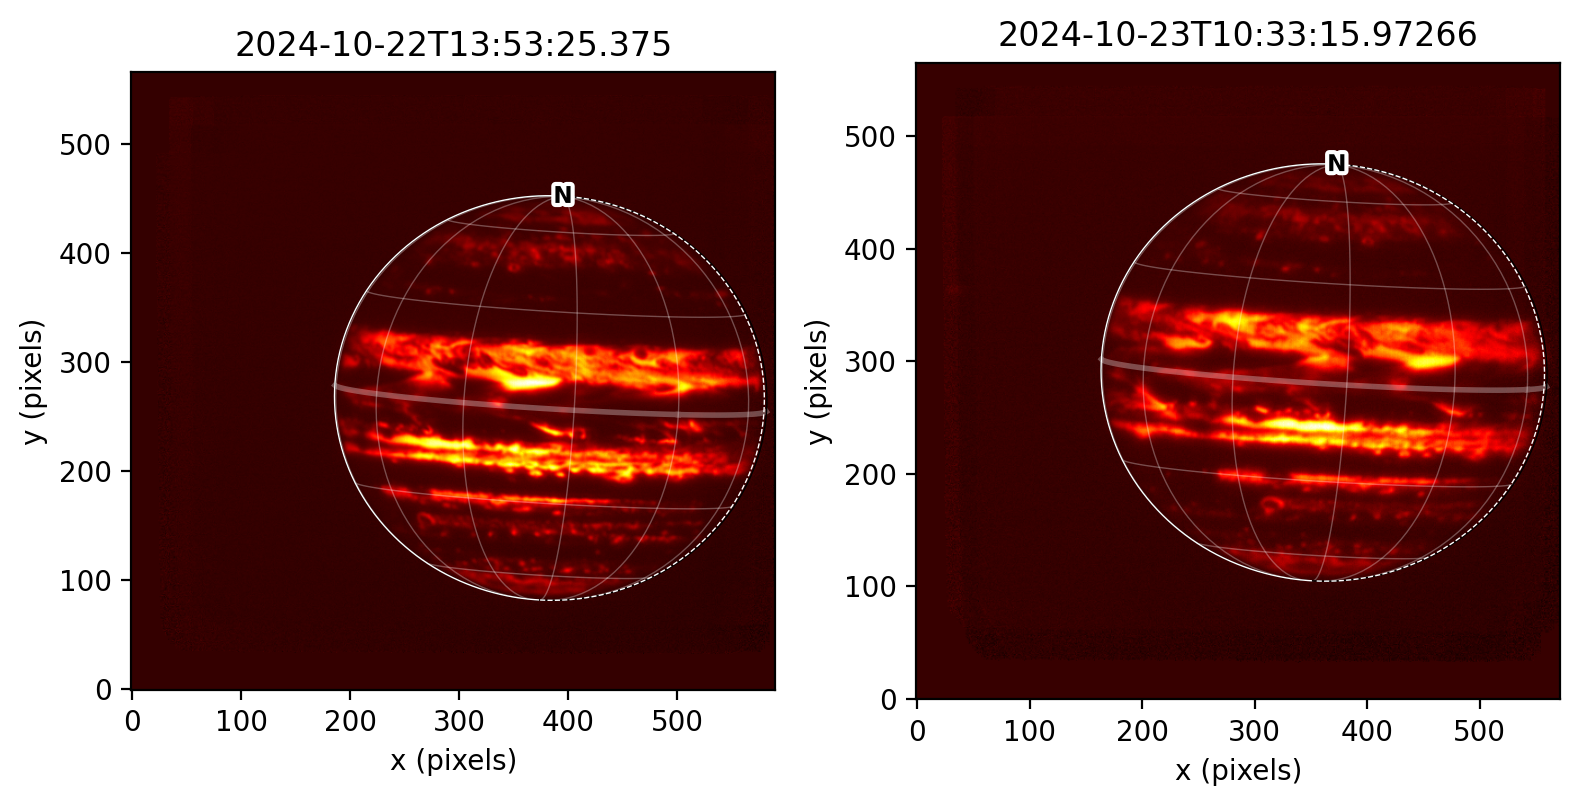

In [31]:

day_str_oct22 = 'spex/2024oct22/'
file_list_oct22 = ['jc505516.fits.gz'] # last image for Oct. 22, 2024

day_str_oct23 = 'spex/2024oct23/'
file_list_oct23 = ['jc057087.fits.gz'] # first image for Oct. 23, 2024

# full path to file
sample_file_ind = 9 # 'spex/2024aug16/jc183201.fits.gz', 'spex/2024aug17/jc329353.fits.gz' have no CX or CY (index: -3)
file_list = [file_paths_list_51[sample_file_ind][0], file_paths_list_51[sample_file_ind][1]]

# testing pairs only about 500 seconds apart. No correlation found as the motion is way below the noise level.
# file_list = [file_paths_list_51[-1][0], file_paths_list_51[-2][0]]


%matplotlib inline

# Number of images
num_images = 2
ncols = math.ceil(math.sqrt(num_images))
nrows = math.ceil(num_images / ncols)

fig1, axs1 = plt.subplots(
nrows=nrows, ncols=ncols, figsize=(8, 4), dpi=200)
axs1 = axs1.flatten()

date_meta_list = []

for ax1, f in zip(axs1, file_list):
    print(f, type(f))
    
    hdul = fits.open(f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    date_tag = hdr['DATE_OBS']
    time_tag = hdr['TIME_OBS']
    utc_str = date_tag + 'T' + time_tag

    date_meta_list.append(utc_str)

    disc_x, disc_y = hdr['CX'], hdr['CY'] # obtained automatically so the disc will be around the correct point
    print(disc_x, type(disc_x))
    print()


    # navigational data made using the GUI - doing it here results in the NASA IRTF being set as observer.
    # Any spice available for it though? Would make things easier!
    observation = planetmapper.Observation(f, 
                                           target='jupiter', 
                                           utc=utc_str, 
                                           observer='EARTH')
    
    # body = planetmapper.Body('jupiter', utc_str, observer='EARTH')
    # body = planetmapper.BodyXY('jupiter', utc_str, observer='EARTH')
    # body.plot_wireframe_radec(show=False)
    # body.set_disc_params(x0=disc_x, y0=disc_y)

    # Run the GUI to fit the disc interactively
    #observation.run_gui() # good for fitting the disc directly
    disc_r0 = r0_array[sample_file_ind]
    # disc_r0 = 198.25


    # plt.figure(dpi=150)
    # observation.plot_backplane_img('LON-GRAPHIC')
    # plt.show()
    
    

    ax1.imshow(observation.data[0, ...], origin='lower', cmap='hot')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)
    observation.plot_wireframe_xy(ax1, formatting={
                                      'grid': {'linestyle': '-', 'linewidth': 0.5, 'alpha': 0.3, 'color':'w'},
                                      'prime_meridian': {'linewidth': 1, 'color': 'r'},
                                      'terminator': {'linewidth': 0.5, 'color':'w'},
                                      'equator': {'linewidth': 2, 'color':'w'},
                                      'limb_illuminated': {'linewidth': 0.5, 'color':'w'},},
                                    indicate_equator=True,
                                )
    # ax1.set_title(hdr['TIME_OBS']+'UTC')
    ax1.set_title(utc_str)
    # plt.show()
fig1.tight_layout()


plt.show()



spex/2024oct23/jc057087.fits.gz <class 'str'>
2024-10-23 10:33:15.97266
361.787 <class 'float'>



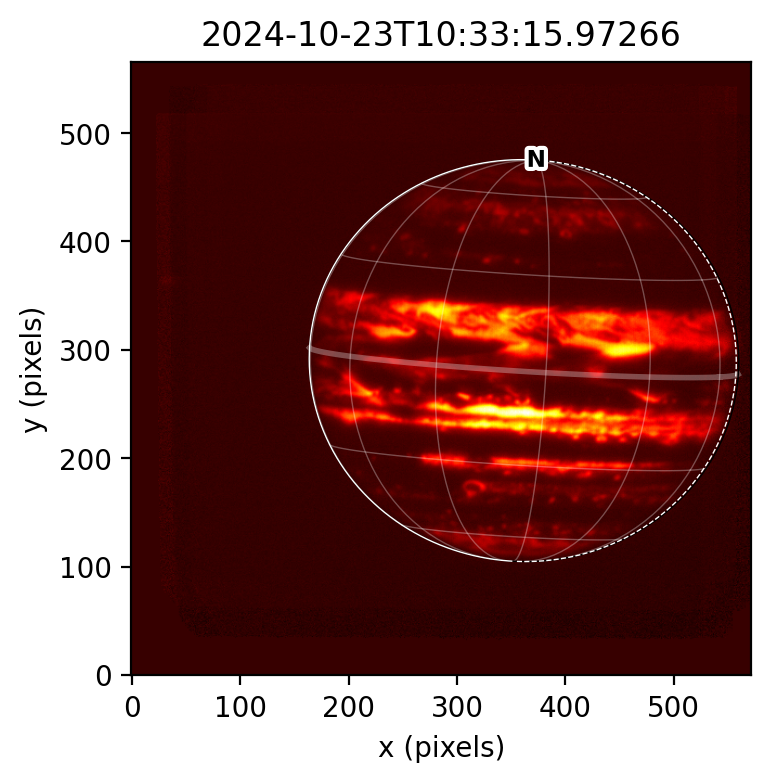

In [29]:

day_str_oct22 = 'spex/2024oct22/'
file_list_oct22 = ['jc505516.fits.gz'] # last image for Oct. 22, 2024

day_str_oct23 = 'spex/2024oct23/'
file_list_oct23 = ['jc057087.fits.gz'] # first image for Oct. 23, 2024

# full path to file
sample_file_ind = 9 # 'spex/2024aug16/jc183201.fits.gz', 'spex/2024aug17/jc329353.fits.gz' have no CX or CY (index: -3)
file_list = [file_paths_list_51[sample_file_ind][1]]

# testing pairs only about 500 seconds apart. No correlation found as the motion is way below the noise level.
# file_list = [file_paths_list_51[-1][0], file_paths_list_51[-2][0]]


%matplotlib inline

# Number of images
num_images = 1
ncols = math.ceil(math.sqrt(num_images))
nrows = math.ceil(num_images / ncols)

fig1, axs1 = plt.subplots(
nrows=nrows, ncols=ncols, figsize=(4, 4), dpi=200)
# axs1 = axs1.flatten()
axs1 = np.array([axs1])
date_meta_list = []

for ax1, f in zip(axs1, file_list):
    print(f, type(f))
    
    hdul = fits.open(f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    date_tag = hdr['DATE_OBS']
    time_tag = hdr['TIME_OBS']
    utc_str = date_tag + 'T' + time_tag

    date_meta_list.append(utc_str)

    disc_x, disc_y = hdr['CX'], hdr['CY'] # obtained automatically so the disc will be around the correct point
    print(disc_x, type(disc_x))
    print()


    # navigational data made using the GUI - doing it here results in the NASA IRTF being set as observer.
    # Any spice available for it though? Would make things easier!
    observation = planetmapper.Observation(f, 
                                           target='jupiter', 
                                           utc=utc_str, 
                                           observer='EARTH')
    
    # body = planetmapper.Body('jupiter', utc_str, observer='EARTH')
    # body = planetmapper.BodyXY('jupiter', utc_str, observer='EARTH')
    # body.plot_wireframe_radec(show=False)
    # body.set_disc_params(x0=disc_x, y0=disc_y)

    # Run the GUI to fit the disc interactively
    #observation.run_gui() # good for fitting the disc directly
    disc_r0 = r0_array[sample_file_ind]
    # disc_r0 = 198.25


    # plt.figure(dpi=150)
    # observation.plot_backplane_img('LON-GRAPHIC')
    # plt.show()
    
    

    ax1.imshow(observation.data[0, ...], origin='lower', cmap='hot')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)
    observation.plot_wireframe_xy(ax1, formatting={
                                      'grid': {'linestyle': '-', 'linewidth': 0.5, 'alpha': 0.3, 'color':'w'},
                                      'prime_meridian': {'linewidth': 1, 'color': 'r'},
                                      'terminator': {'linewidth': 0.5, 'color':'w'},
                                      'equator': {'linewidth': 2, 'color':'w'},
                                      'limb_illuminated': {'linewidth': 0.5, 'color':'w'},},
                                    indicate_equator=True,
                                )
    # ax1.set_title(hdr['TIME_OBS']+'UTC')
    ax1.set_title(utc_str)
    # plt.show()
fig1.tight_layout()


plt.show()



In [32]:
delta_t = ZWP_Class.getTemporalDifference(file_list)
print('Time elapsed between observations (seconds): ', delta_t)
print('The following values make sense. Voyager, Cassini, and HST observations show around a 80-95 m/s range at 7˚.')
print()
# getSpeedatLat(1e-2, delta_t)

Time elapsed between observations (seconds):  74391.0
The following values make sense. Voyager, Cassini, and HST observations show around a 80-95 m/s range at 7˚.



In [33]:
file_list

['spex/2024oct22/jc451486.fits.gz', 'spex/2024oct23/jc057087.fits.gz']

In [34]:
text_ex, time_ex = '2024-10-22', '14:01:56.875'
print(text_ex.split("-"))
print(time_ex.split(":"))
print()
getTemporalDifference(file_list)


['2024', '10', '22']
['14', '01', '56.875']



74391.0

2024-10-22 13:53:25.375
2024-10-23 10:33:15.97266


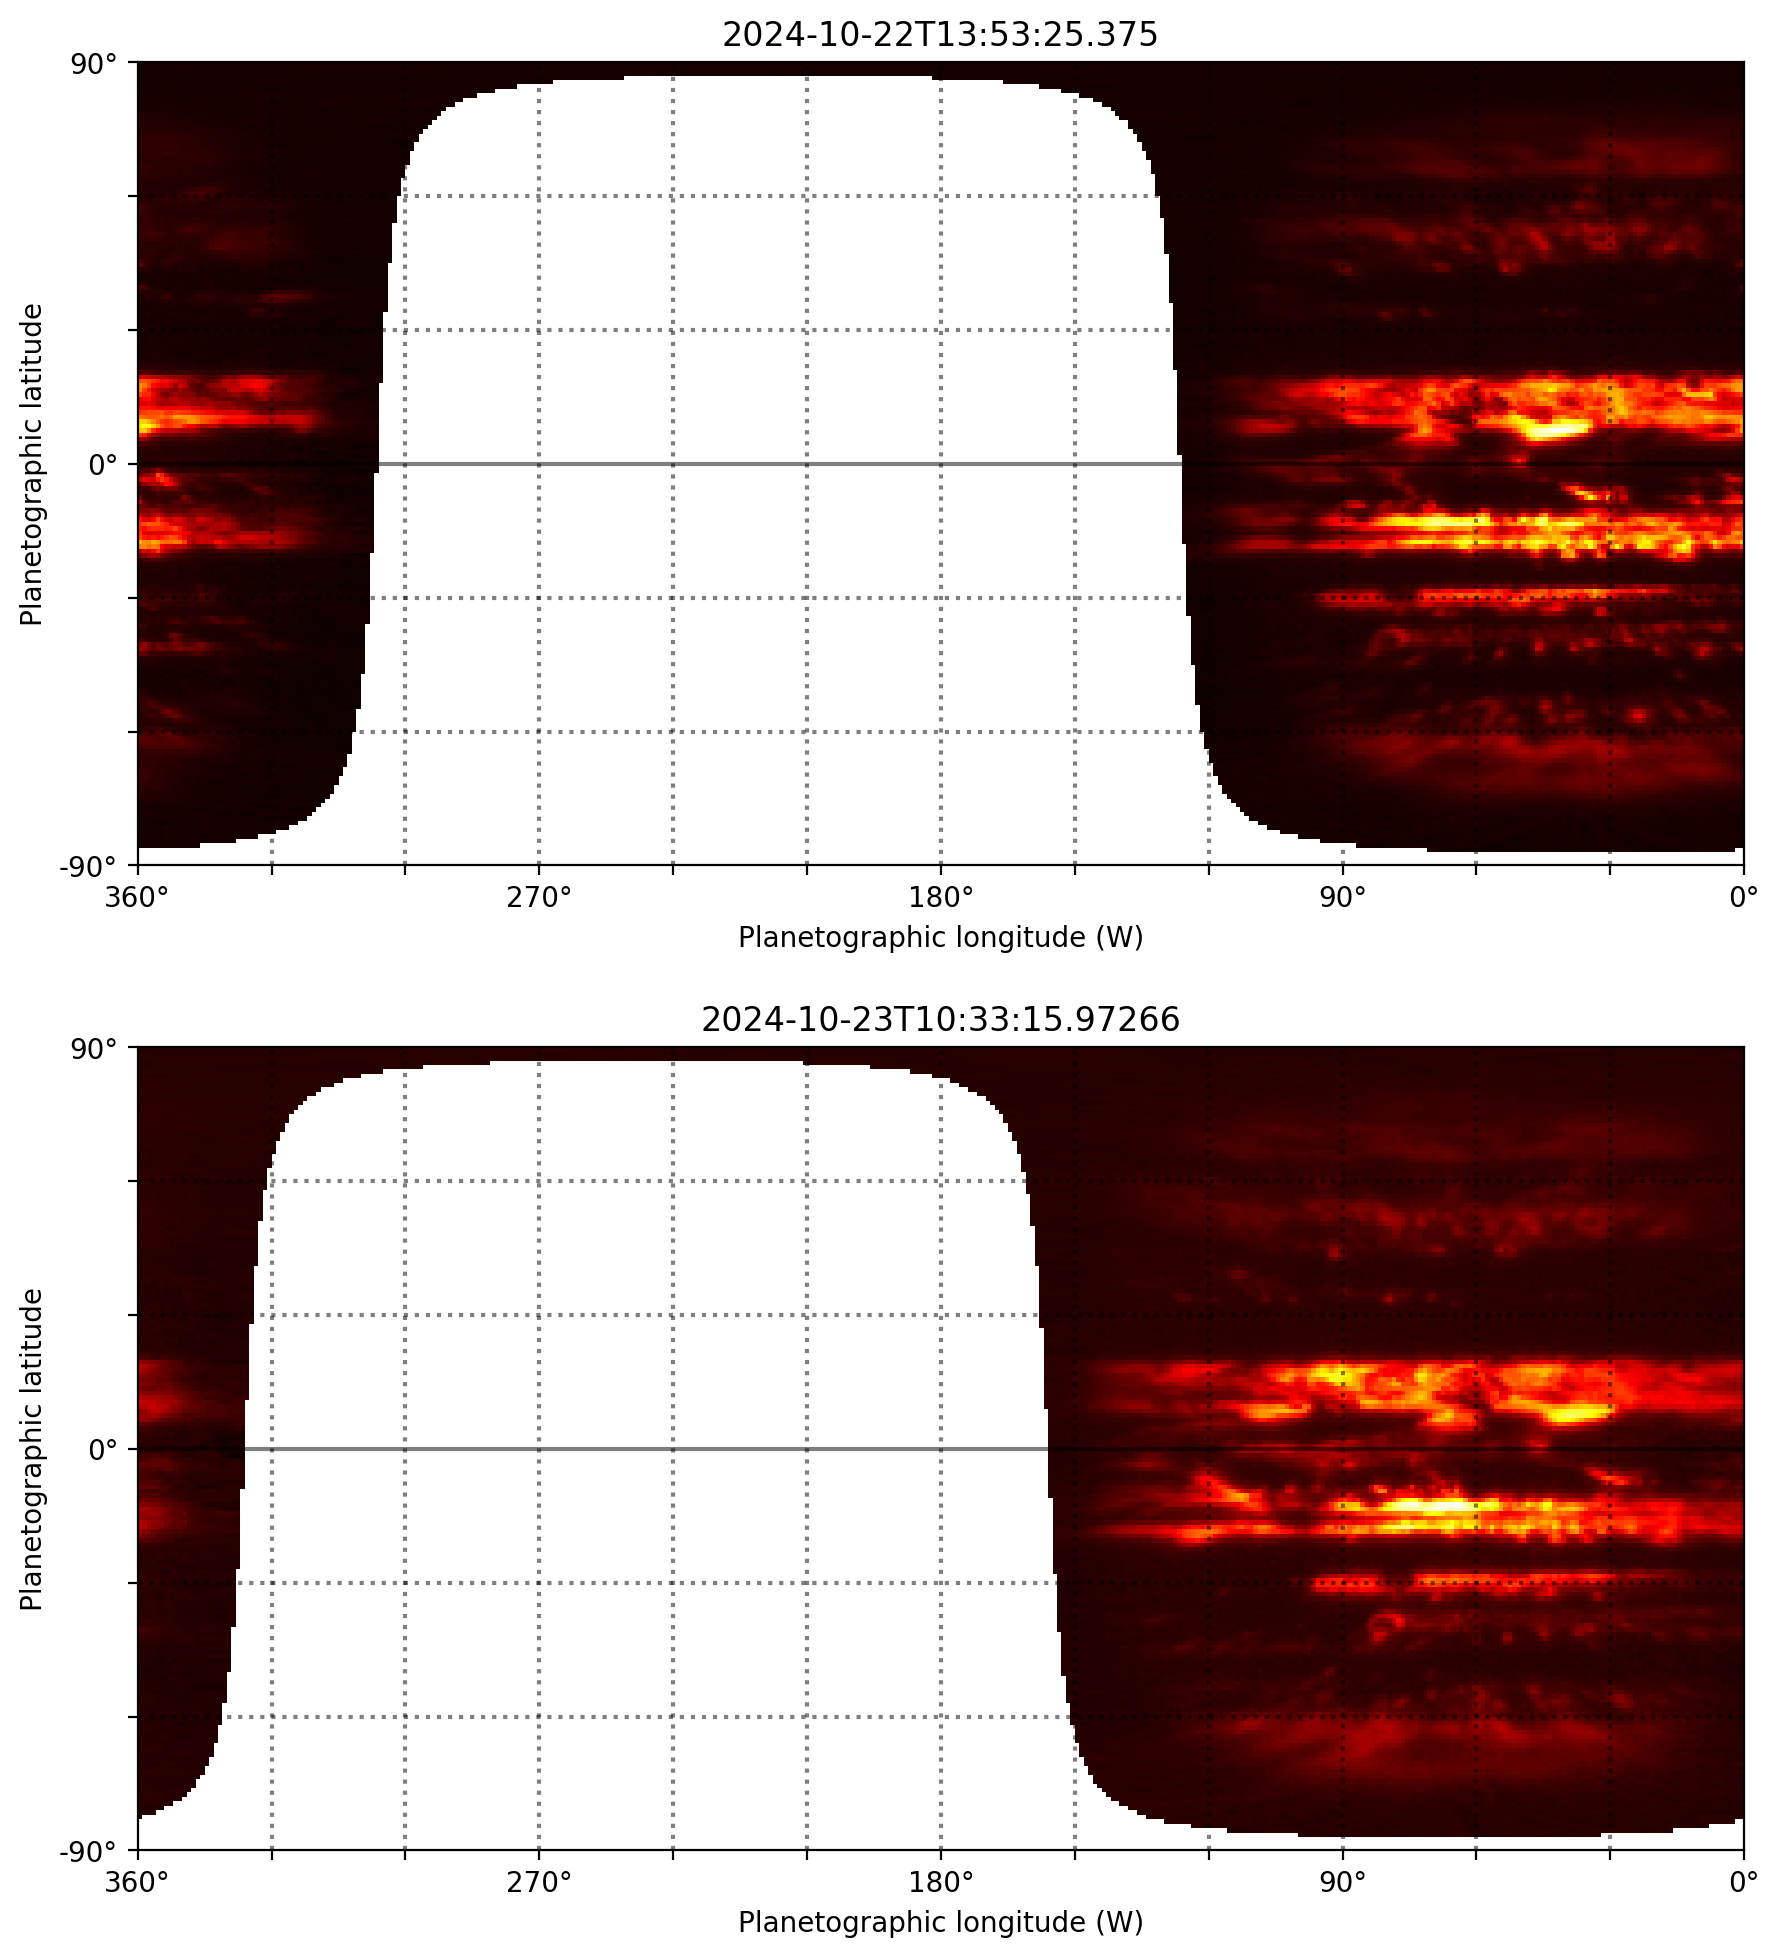

(1, 180, 360)


In [35]:

fig3, axs3 = plt.subplots(
nrows=2, ncols=1, figsize=(9, 10), dpi=200)
axs3 = axs3.flatten()

cmap_meta_list = []
obs_meta_list = []

'''
This block only works with non-interactive plotting for some stupid reason! It has to do with backend Qt5Agg and the plt.show() command.
It's possible that the observation object messes things up due to how the internal plotting of planetmapper is defined.
Just leave it alone and keep it inline. Use contourf in a different cell if needed ffs...
'''
# keep this here so this cells work well - otherwise planetmapper has a seizure. # KEEP THIS LINE
%matplotlib inline 

for ax3, f in zip(axs3, file_list):
    
    hdul = fits.open(f)
    hdr = hdul[0].header
    print(hdr['DATE_OBS'], hdr['TIME_OBS'])
    date_tag = hdr['DATE_OBS']
    time_tag = hdr['TIME_OBS']
    utc_str = date_tag + 'T' + time_tag
    disc_x, disc_y = hdr['CX'], hdr['CY']
    
    observation = planetmapper.Observation(f, 
                                            target='jupiter', 
                                            utc=utc_str, 
                                            observer='EARTH')
    observation.set_disc_params(x0=disc_x, y0=disc_y, r0=disc_r0)   
    obs_meta_list.append(observation)

    mapped_data = observation.get_mapped_data('linear')  # get the mapped data
    cmap_meta_list.append(mapped_data)
    
    # Display mapped image and add a useful annotation
    observation.imshow_map(mapped_data[0, ...], ax3, cmap='hot')
    # ax3.contourf(np.linspace(360, 0,360), np.linspace(-90, 90,180), mapped_data[0, ...], 256, cmap='hot')
    # ax3.set_title(hdr['TIME_OBS']+'UTC')
    # ax3.set_ylim(-60, 60)
    ax3.set_title(utc_str)

fig3.tight_layout()

plt.show()

print(cmap_meta_list[0].shape)

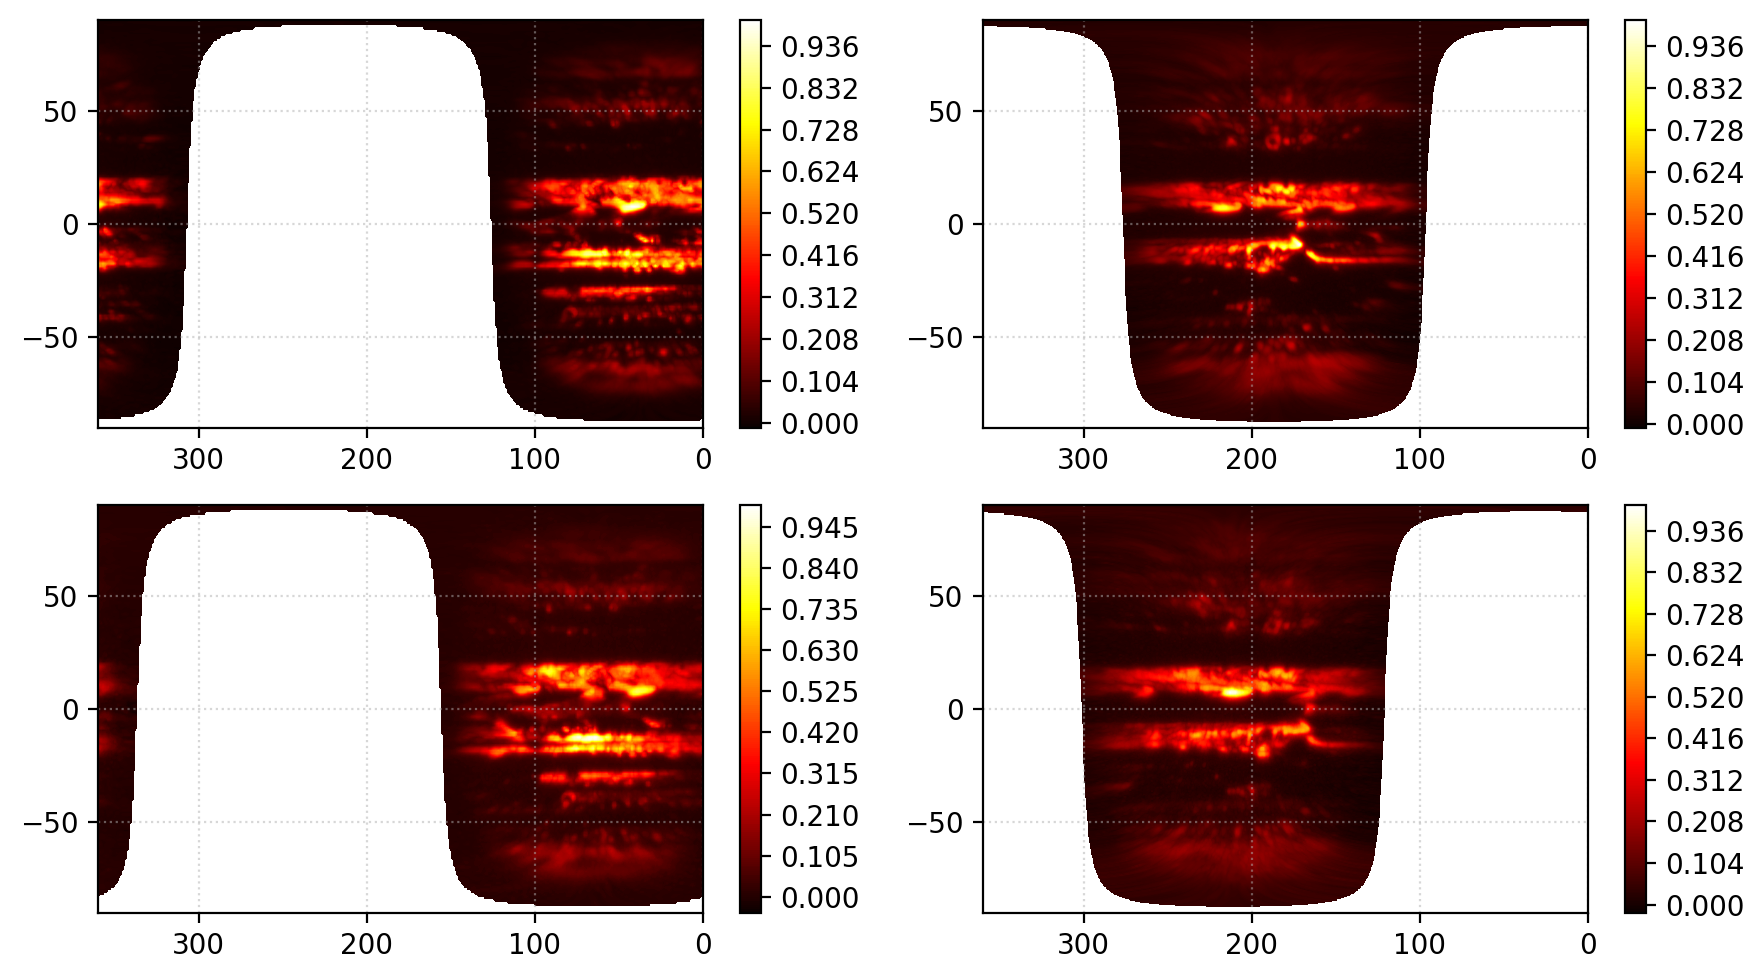

(360, 720) (180, 360)


'\nNOTE: The cmap_file_list has the same data with the same or higher resolution as expected but the order is different.\nThus, the index, sample_file_ind, should not be used to plot both. The indices have to be checked explicitly. Do this once to convince\nyourself that it is fine but then move on. It would be beneficial to obtain the date-time objects from the cyl. map headers \nso that the records are kept consistent.\n'

In [36]:
%matplotlib inline

plt.figure(figsize=(9,5), dpi=200) 

# plt.figure(figsize=(9,4), dpi=200)
plt.subplot(221)
plt.contourf(long_array, lat_array, cmap_meta_list[0][0, ...]/np.nanmax(cmap_meta_list[0][0, ...]), 256, cmap='hot')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.colorbar()
# plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')

# plt.figure(figsize=(9,4), dpi=200)
plt.subplot(223)
plt.contourf(long_array, lat_array, cmap_meta_list[1][0, ...]/np.nanmax(cmap_meta_list[1][0, ...]), 256, cmap='hot')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.colorbar()
# plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')

sample_file_ind_4_cmaps = 1
# plt.figure(figsize=(9,4), dpi=200)
plt.subplot(222)
plt.contourf(np.linspace(360, 0, test_compatibility_func[sample_file_ind_4_cmaps][0].shape[-1]), 
             np.linspace(-90, 90, test_compatibility_func[sample_file_ind_4_cmaps][0].shape[0]), 
             test_compatibility_func[sample_file_ind_4_cmaps][0]/np.nanmax(test_compatibility_func[sample_file_ind_4_cmaps][0]), 256, cmap='hot')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.colorbar()

# plt.figure(figsize=(9,4), dpi=200) 
plt.subplot(224)
plt.contourf(np.linspace(360, 0, test_compatibility_func[sample_file_ind_4_cmaps][0].shape[-1]), 
             np.linspace(-90, 90, test_compatibility_func[sample_file_ind_4_cmaps][0].shape[0]), 
             test_compatibility_func[sample_file_ind_4_cmaps][1]/np.nanmax(test_compatibility_func[sample_file_ind_4_cmaps][1]), 256, cmap='hot')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.colorbar()

plt.tight_layout()
plt.show()

print(test_compatibility_func[sample_file_ind_4_cmaps][0].shape, cmap_meta_list[0][0, ...].shape)

'''
NOTE: The cmap_file_list has the same data with the same or higher resolution as expected but the order is different.
Thus, the index, sample_file_ind, should not be used to plot both. The indices have to be checked explicitly. Do this once to convince
yourself that it is fine but then move on. It would be beneficial to obtain the date-time objects from the cyl. map headers 
so that the records are kept consistent.
'''

In [37]:
# aux0 = test_compatibility_func[sample_file_ind_4_cmaps][0]
# aux0[aux0 <= 0] = np.nan
# print(aux0)
test_compatibility_func[sample_file_ind_4_cmaps][0] / np.nanmax(test_compatibility_func[sample_file_ind_4_cmaps][0])

array([[       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       [       nan,        nan,        nan, ...,        nan,        nan,
               nan],
       ...,
       [0.03008825, 0.02988224, 0.02967676, ..., 0.03070844, 0.03050141,
        0.03029477],
       [0.03169432, 0.03159019, 0.03148608, ..., 0.03200758, 0.03190294,
        0.03179848],
       [0.033365  , 0.033365  , 0.033365  , ..., 0.033365  , 0.033365  ,
        0.033365  ]], shape=(360, 720), dtype=float32)

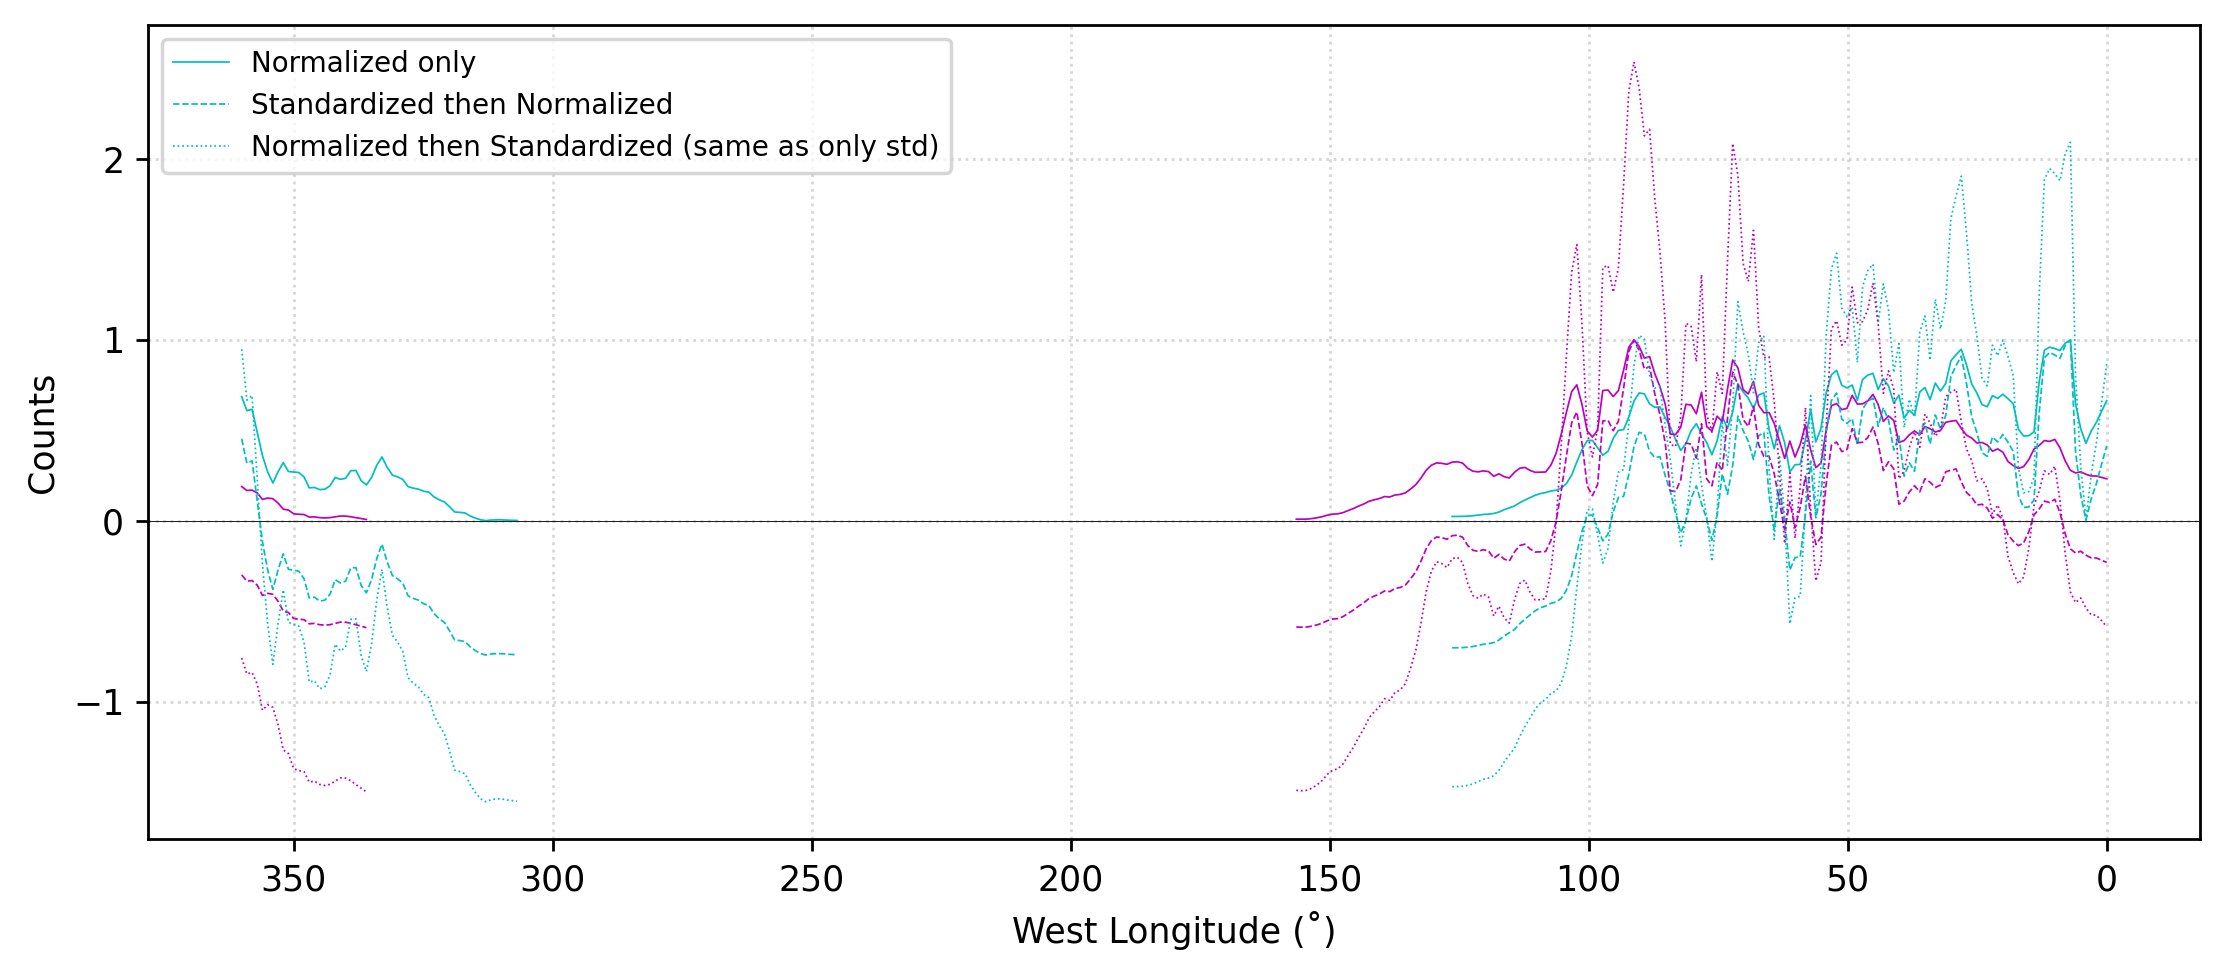

In [60]:
%matplotlib inline

test_lat = 15
test_f1 = (cmap_meta_list[0][0, 90+test_lat, :] - np.nanmean(cmap_meta_list[0][0, 90+test_lat, :]))/np.nanstd(cmap_meta_list[0][0, 90+test_lat, :])
test_f2 = (cmap_meta_list[1][0, 90+test_lat, :] - np.nanmean(cmap_meta_list[1][0, 90+test_lat, :]))/np.nanstd(cmap_meta_list[1][0, 90+test_lat, :])
test_f1_normalized_only = cmap_meta_list[0][0, 90+test_lat, :] / np.nanmax(cmap_meta_list[0][0, 90+test_lat, :])
test_f2_normalized_only = cmap_meta_list[1][0, 90+test_lat, :] / np.nanmax(cmap_meta_list[1][0, 90+test_lat, :])

test_f1_norm_std = (test_f1_normalized_only - np.nanmean(test_f1_normalized_only)) / np.nanstd(test_f1_normalized_only)
test_f2_norm_std = (test_f2_normalized_only - np.nanmean(test_f2_normalized_only)) / np.nanstd(test_f2_normalized_only)

plt.figure(figsize=(9,4), dpi=250)

# plt.plot(long_array, cmap_meta_list[0][0, 90+test_lat, :], ls='dashdot', lw=0.5, color='c', label='Raw')
# plt.plot(long_array, cmap_meta_list[1][0, 90+test_lat, :], ls='dashdot', color='m', lw=0.5)

plt.plot(long_array, test_f1_normalized_only, lw=0.5, color='c', label='Normalized only')
plt.plot(long_array, test_f2_normalized_only, color='m', lw=0.5)

plt.plot(long_array, test_f1/np.nanmax(test_f1), ls='dashed', color='c', lw=0.5, label='Standardized then Normalized')
plt.plot(long_array, test_f2/np.nanmax(test_f2), ls='dashed', color='m', lw=0.5)

plt.plot(long_array, test_f1_norm_std, ls=':', color='c', lw=0.5, label='Normalized then Standardized (same as only std)')
plt.plot(long_array, test_f2_norm_std, ls=':', color='m', lw=0.5)

# plt.plot(long_array, np.roll(cmap_meta_list[1][0, 90, :], 1), color='c', lw=0.7, ls=':', alpha=0.5)
plt.axhline(0.0, color='k', lw=0.25)
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.xlabel('West Longitude (˚)'), plt.ylabel('Counts')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
np.mean(cmap_meta_list[0][0, 90+test_lat, :])

np.float64(nan)

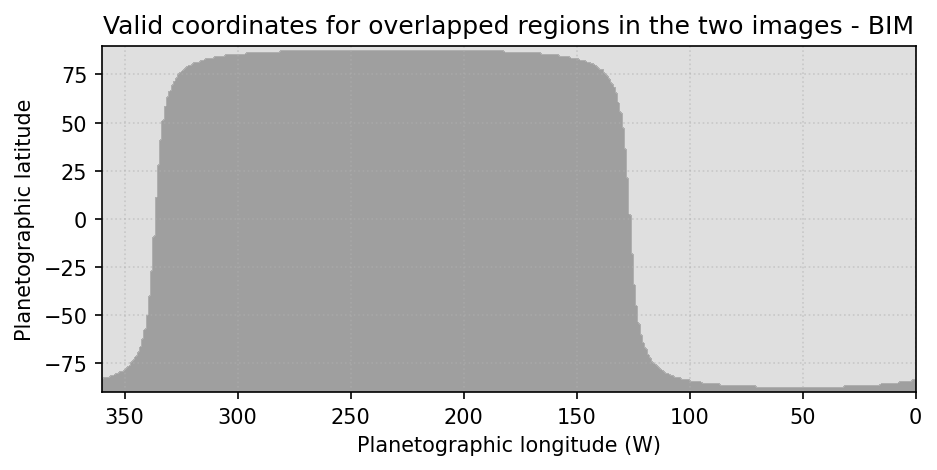

42.04012345679013  % of the map is valid for use in a ZWP generation
Original map percentages: (Makes sense as it is approximately half of the planet)
49.99691358024692  %
49.98456790123457  %


In [61]:
# Boolean Intersection Map (BIM)
test_bool_intersect = getValidLatLonRange(cmap_meta_list[0][0, ...], cmap_meta_list[1][0, ...])
test_bool_cmap0 = getValidLatLonRange(cmap_meta_list[0][0, ...], np.ones((180,360)))
test_bool_cmap1 = getValidLatLonRange(cmap_meta_list[1][0, ...], np.ones((180,360)))

%matplotlib inline
plt.figure(figsize=(7,3), dpi=150)
plt.contourf(long_array, lat_array, test_bool_intersect, 1, cmap='gray', alpha=0.5)
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
# plt.colorbar()
plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')
plt.title('Valid coordinates for overlapped regions in the two images - BIM')
plt.show()

print((np.sum(test_bool_intersect) / test_bool_intersect.size) * 100, ' % of the map is valid for use in a ZWP generation')
print('Original map percentages: (Makes sense as it is approximately half of the planet)')
print((np.sum(test_bool_cmap0) / test_bool_cmap0.size) * 100, ' %')
print((np.sum(test_bool_cmap1) / test_bool_cmap1.size) * 100, ' %')

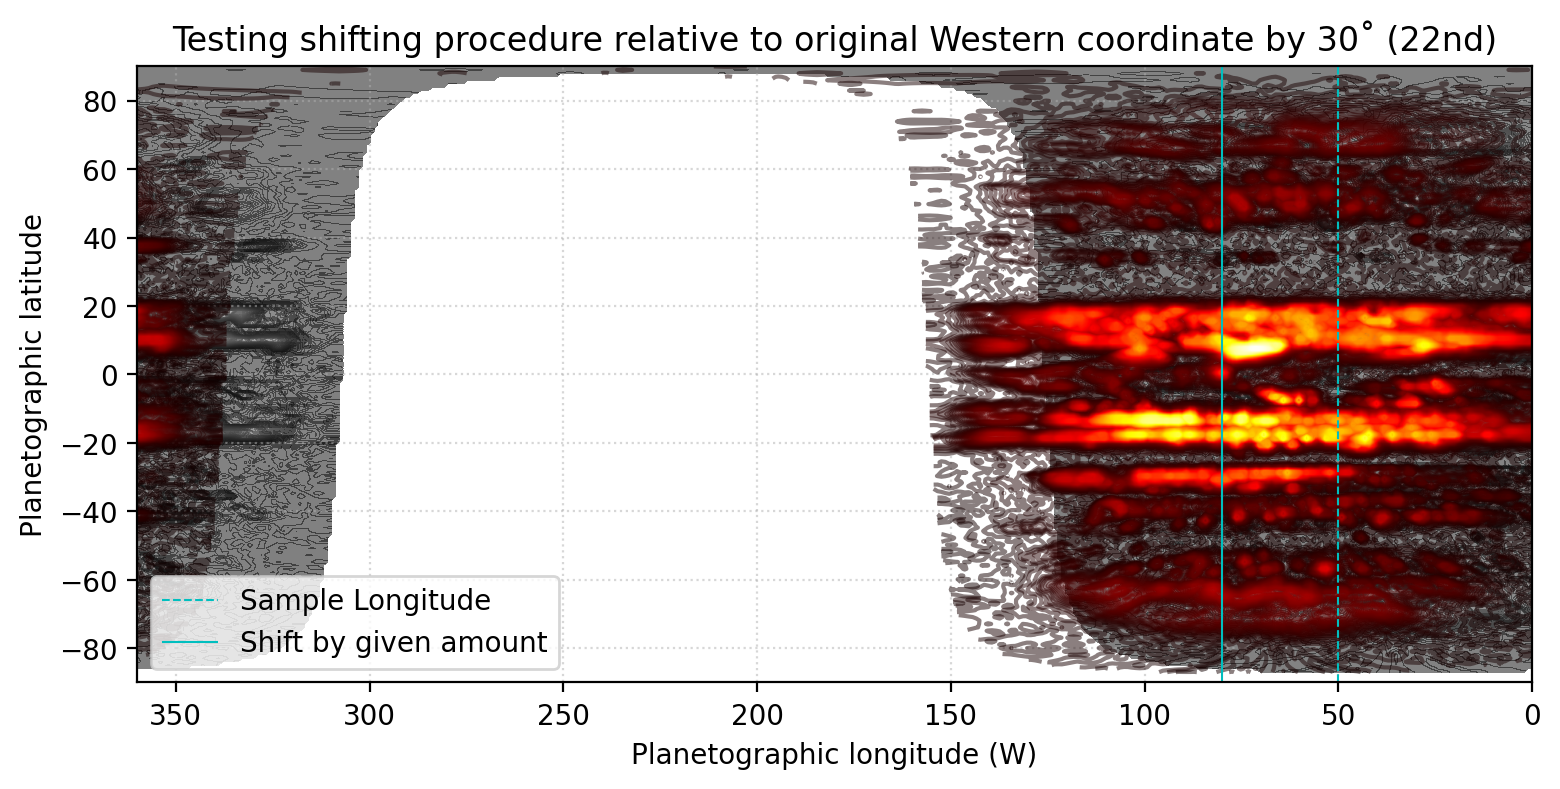

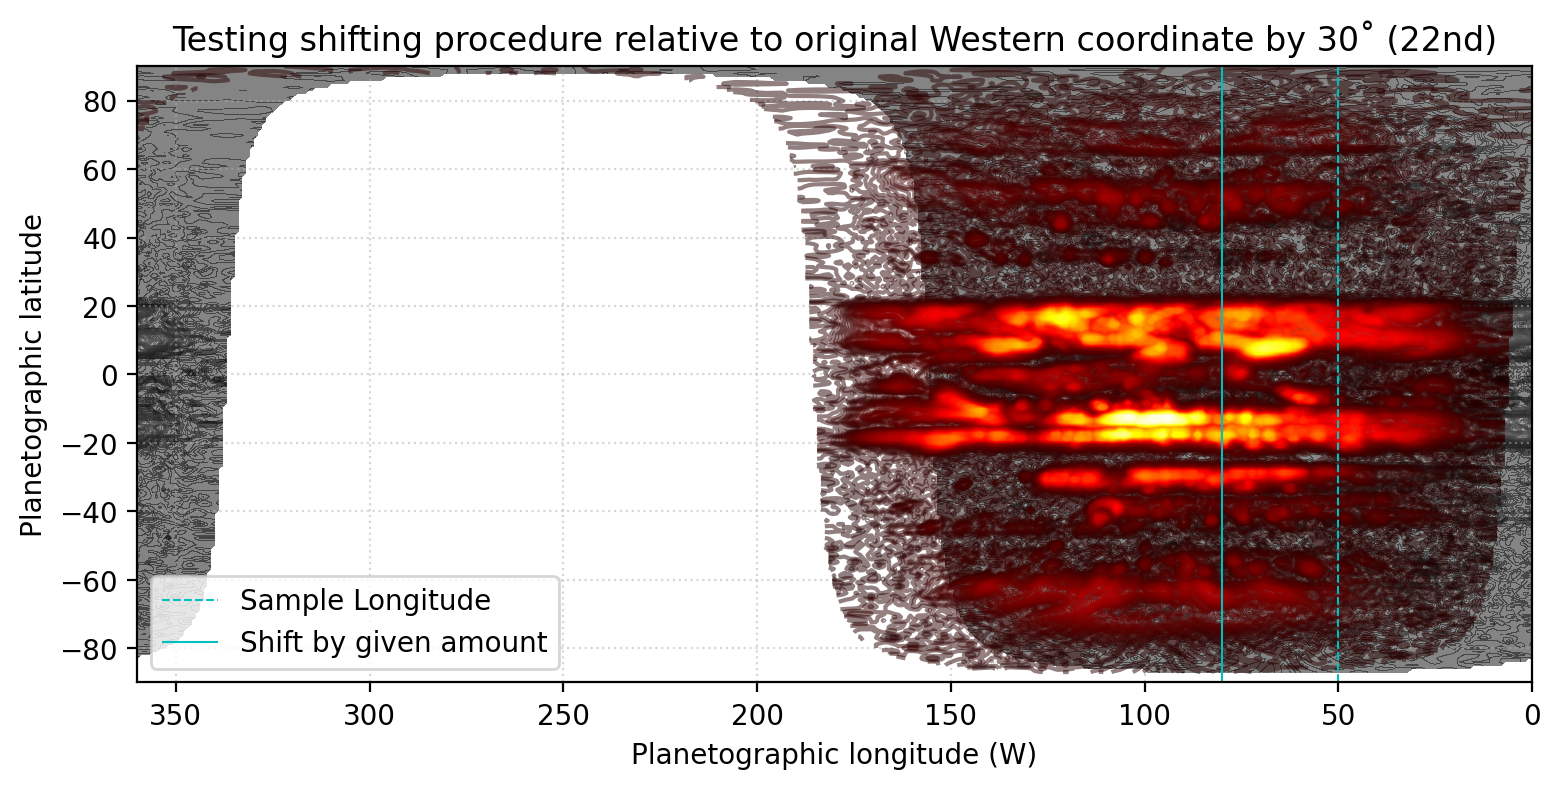

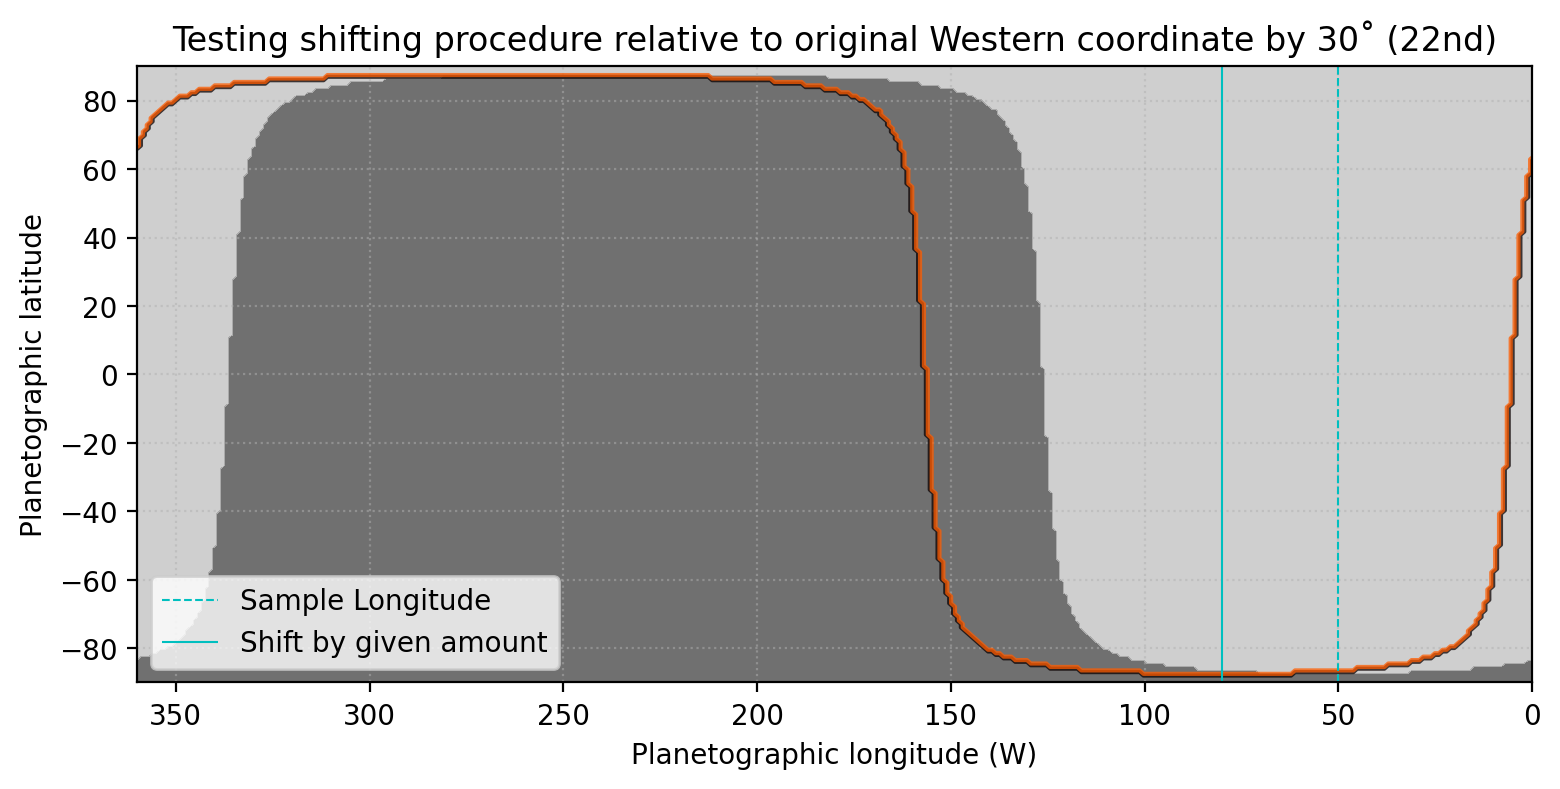

In [64]:
orig_ex_long = 50
test_shift_long = 30#90

test_long_shift_1, test_map_shift_1 = shiftMap(long_array, cmap_meta_list[0][0, ...], test_shift_long)
test_long_shift_2, test_map_shift_2 = shiftMap(long_array, cmap_meta_list[1][0, ...], test_shift_long)
_, intersect_shift_map = shiftMap(long_array, test_bool_intersect, test_shift_long)

%matplotlib inline

plt.figure(figsize=(9,4), dpi=200)
plt.contourf(long_array, lat_array, cmap_meta_list[0][0, ...], 256, cmap='gray', alpha=0.5)
plt.contour(long_array, lat_array, test_map_shift_1, 256, cmap='hot', alpha=0.5)
plt.vlines(orig_ex_long, min(lat_array), max(lat_array), color='c', ls='dashed', lw=0.75, label='Sample Longitude')
plt.vlines(orig_ex_long + test_shift_long, min(lat_array), max(lat_array), color='c', lw=0.75, label='Shift by given amount')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.title('Testing shifting procedure relative to original Western coordinate by ' + str(test_shift_long) + '˚ (22nd)')
plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')
plt.legend(loc='lower left')

plt.figure(figsize=(9,4), dpi=200)
plt.contourf(long_array, lat_array, cmap_meta_list[1][0, ...], 256, cmap='gray', alpha=0.5)
plt.contour(long_array, lat_array, test_map_shift_2, 256, cmap='hot', alpha=0.5)
plt.vlines(orig_ex_long, min(lat_array), max(lat_array), color='c', ls='dashed', lw=0.75, label='Sample Longitude')
plt.vlines(orig_ex_long + test_shift_long, min(lat_array), max(lat_array), color='c', lw=0.75, label='Shift by given amount')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.title('Testing shifting procedure relative to original Western coordinate by ' + str(test_shift_long) + '˚ (22nd)')
plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')
plt.legend(loc='lower left')
# plt.show()

plt.figure(figsize=(9,4), dpi=200)
plt.contourf(long_array, lat_array, test_bool_intersect, 1, cmap='gray', alpha=0.75)
plt.contour(long_array, lat_array, intersect_shift_map, 1, cmap='hot', alpha=0.75)
plt.vlines(orig_ex_long, min(lat_array), max(lat_array), color='c', ls='dashed', lw=0.75, label='Sample Longitude')
plt.vlines(orig_ex_long + test_shift_long, min(lat_array), max(lat_array), color='c', lw=0.75, label='Shift by given amount')
plt.gca().invert_xaxis()
plt.grid(True, 'both', ls=':', alpha=0.5)
plt.title('Testing shifting procedure relative to original Western coordinate by ' + str(test_shift_long) + '˚ (22nd)')
plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')
plt.legend(loc='lower left')
plt.show()


In [ ]:
'''
Pre- and post margin application longitudes:
'''

boolean_mask = defineLongThresh(test_bool_intersect, long_array, lat_array, crit_lat=50)  # longitudes from intersection
boolean_mask_after_margin = applyMargin(boolean_mask, long_array, margin=5)  # (1, 360) boolean
print(boolean_mask)
# print()

# pre-margin
longitude_masked = np.ma.masked_array(long_array, np.logical_not(boolean_mask))
print(longitude_masked) 
print()

# post-margin
longitude_masked_margin = np.ma.masked_array(long_array, np.logical_not(boolean_mask_after_margin))
print(longitude_masked_margin)
print(bool(boolean_mask_after_margin[0]))
# print(shiftMap(long_array, boolean_mask_after_margin, 0))

70 219
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0

In [ ]:
%matplotlib inline

sliding_window = 50

plt.figure(figsize=(6,3), dpi=250)
plt.contourf(long_array, lat_array, test_bool_intersect, 1, cmap='gray', alpha=0.5)
plt.hlines(critical_lat, min(long_array), max(long_array), color='k', ls='dashed', lw=0.75)
plt.hlines(-critical_lat, min(long_array), max(long_array), color='k', ls='dashed', lw=0.75)

pre_margin_indices  = np.where(abs(np.diff(boolean_mask)) == 1)[0]
post_margin_indices = np.where(abs(np.diff(boolean_mask_after_margin)) == 1)[0]
# print(pre_margin_indices, post_margin_indices)

loc = np.where(abs(np.diff(margin_applied_in_func_shifted)) == 1)[0]
print(loc)
sliding_window_len = 30
allowed_slides = np.sum(margin_applied_in_func_shifted)

# def getSlidingWindowBoolArray(margin_applied_in_func_shifted, sliding_window_len):
#     loc = np.where(abs(np.diff(margin_applied_in_func_shifted)) == 1)[0]
#     RHS_bound = loc[0]
RHS_bound = loc[0]
counter = 0
while RHS_bound+sliding_window_len <= loc[-1]:
    aux_bool = np.zeros_like(margin_applied_in_func_shifted)
    aux_bool[RHS_bound + 1:RHS_bound + 1 + sliding_window_len] = 1
    loc_aux_bool = np.where(abs(np.diff(aux_bool)) == 1)[0]
    RHS_bound += 9 #1
    print(counter, (loc[-1]-loc[0]-sliding_window)//9, loc_aux_bool, aux_bool[loc_aux_bool[0]+1], aux_bool[loc_aux_bool[1]])
    counter +=1

# print(margin_applied_in_func_shifted.astype(bool))
# print(long_array.shape, long_array[margin_applied_in_func_shifted.astype(bool)])

# plt.vlines(long_array[pre_margin_indices[0]], min(lat_array), max(lat_array), color='k', ls='dashed', lw=0.75, label='pre-margin')
# plt.vlines(long_array[pre_margin_indices[1]], min(lat_array), max(lat_array), color='k', ls='dashed', lw=0.75)

# plt.vlines(long_array[post_margin_indices[0]], min(lat_array), max(lat_array), color='c', ls='dashed', lw=0.75, label='post-margin')
# plt.vlines(long_array[post_margin_indices[1]], min(lat_array), max(lat_array), color='c', ls='dashed', lw=0.75)

# plt.vlines(long_array[post_margin_indices[1]-sliding_window], -critical_lat, critical_lat, color='m', ls='dashed', lw=0.75, label='sliding window')
# plt.vlines(long_array[post_margin_indices[1]], -critical_lat, critical_lat, color='m', ls='dashed', lw=0.75)

# plt.gca().invert_xaxis()
# plt.legend(loc='upper right', fontsize=6)
# plt.grid(True, 'both', ls=':', alpha=0.5)
# # plt.colorbar()
# plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Planetographic latitude')
# plt.title('BIM')
# plt.tight_layout()
# plt.show()

[ 74 214]
0 10 [ 74 104] 1.0 1.0
1 10 [ 83 113] 1.0 1.0
2 10 [ 92 122] 1.0 1.0
3 10 [101 131] 1.0 1.0
4 10 [110 140] 1.0 1.0
5 10 [119 149] 1.0 1.0
6 10 [128 158] 1.0 1.0
7 10 [137 167] 1.0 1.0
8 10 [146 176] 1.0 1.0
9 10 [155 185] 1.0 1.0
10 10 [164 194] 1.0 1.0
11 10 [173 203] 1.0 1.0
12 10 [182 212] 1.0 1.0


In [ ]:
print(boolean_mask)
print()
print(applyMargin(boolean_mask, long_array, margin=3))

lat_count = test_bool_intersect.shape[0]
print(lat_count, boolean_mask_after_margin.shape, test_bool_intersect.shape)
velocities = np.full(lat_count, np.nan)  # Initialize with NaN
print(velocities.shape)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [ ]:

# basic intersection at latitude 0:
# print(test_bool_intersect[90, :])

a = applyMargin(test_bool_intersect[90, :], long_array, margin=3)
print(a)



66 222
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:

critical_lat = 50
shifted_f1, shifted_f2, shifted_BIM, margin_applied_in_func_shifted, final_longitudes_masked_shifted, corr_1D, corr_1D_coeff = ZWP_Class.getFullLatitudinalCorrelation(
                            cmap_meta_list[0][0, ...], cmap_meta_list[1][0, ...], 
                            long_array, lat_array, shift_long=90, crit_lat=critical_lat, 
                            margin=5, max_delta_long=8, force_shift=False, sliding_window_boolean=False, lat_res_tol=1e-2)

70 219
No shift applied.

Entered sub function


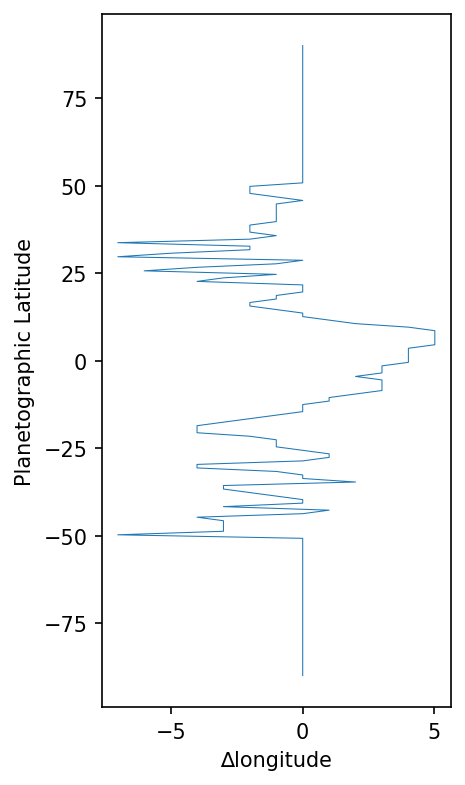

73962.0


In [ ]:
zwp_5microns = -ZWP_Class.getSpeedatLat(corr_1D, delta_t) # minus is necessary to match the other observations of the wind speed.
# smooth_zwp_5microns = getSmoothedProfile(zwp_5microns, 7, 2)
smooth_zwp_5microns = ZWP_Class.getSmoothedProfile(zwp_5microns, lat_array, jet_width=7, poly_order=3)

hst_wind_1D = np.genfromtxt('Simon+2015_ZWP_HST.csv', delimiter=",", dtype=None, encoding=None, names=True)
opal_nov_2024_df = pd.read_excel('OPAL/2024nov_jup_502.xlsx')

# convert HST planetographic latitudes to planetocentric
centric_lat_HST = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, opal_nov_2024_df['LAT']))
centric_lat_HST_2015 = np.rad2deg(ZWP_Class.planeto_Graphic2Centric(R_J, R_J_p, hst_wind_1D['y']))

%matplotlib inline
y_lim_range = 50 #critical_lat - critical_lat*0.05 # -5% for aesthetics...
plt.figure(figsize=(3,6), dpi=150)
# plt.plot(corr_1D / 20.5219444, lat_array)
# plt.plot(corr_1D * 71492e3 / 73879, lat_array)
plt.plot(-corr_1D, lat_array, lw=0.5)
plt.xlabel('∆longitude')
plt.ylabel('Planetographic Latitude')
# plt.xlim(-1000, 1000)
# plt.ylim(-y_lim_range, y_lim_range)
plt.show()
print(delta_t)

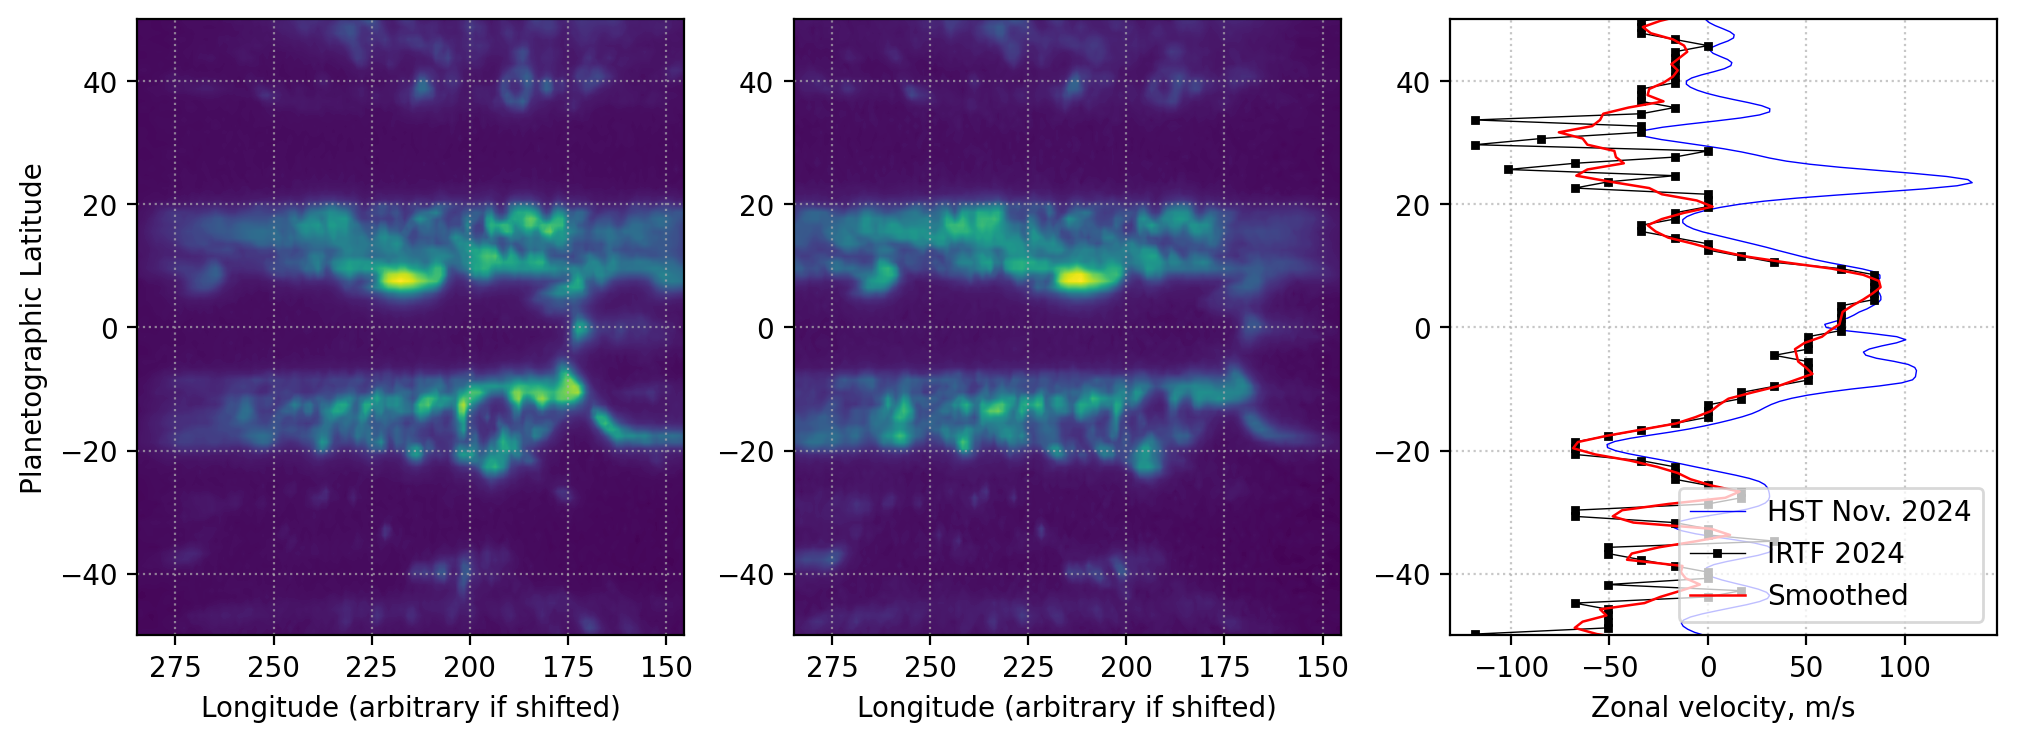

140
140
[284.79108635 283.78830084 282.78551532 281.78272981 280.77994429
 279.77715877 278.77437326 277.77158774 276.76880223 275.76601671
 274.7632312  273.76044568 272.75766017 271.75487465 270.75208914
 269.74930362 268.74651811 267.74373259 266.74094708 265.73816156
 264.73537604 263.73259053 262.72980501 261.7270195  260.72423398
 259.72144847 258.71866295 257.71587744 256.71309192 255.71030641
 254.70752089 253.70473538 252.70194986 251.69916435 250.69637883
 249.69359331 248.6908078  247.68802228 246.68523677 245.68245125
 244.67966574 243.67688022 242.67409471 241.67130919 240.66852368
 239.66573816 238.66295265 237.66016713 236.65738162 235.6545961
 234.65181058 233.64902507 232.64623955 231.64345404 230.64066852
 229.63788301 228.63509749 227.63231198 226.62952646 225.62674095
 224.62395543 223.62116992 222.6183844  221.61559889 220.61281337
 219.61002786 218.60724234 217.60445682 216.60167131 215.59888579
 214.59610028 213.59331476 212.59052925 211.58774373 210.58495822
 20

In [ ]:
# date_meta_list # time difference of 20 hours, 31 minutes, and 19 seconds (20.5219444 hours)
# plt.imshow(shifted_f1, origin='lower', alpha=0.5)
# plt.imshow(shifted_f2, origin='lower', alpha=0.5)
# plt.imshow(shifted_BIM, origin='lower', alpha=0.5)

%matplotlib inline
fig, axs = plt.subplots(
nrows=1, ncols=3, figsize=(12, 4), dpi=200)
axs[0].contourf(long_array[margin_applied_in_func_shifted.astype(bool)], lat_array, shifted_f1[:, margin_applied_in_func_shifted.astype(bool)], 256, alpha=1)
# axs[0].contour(long_array[margin_applied_in_func_shifted.astype(bool)], lat_array, shifted_f2[:, margin_applied_in_func_shifted.astype(bool)], 128, cmap='bone', alpha=0.25)
axs[1].contourf(long_array[margin_applied_in_func_shifted.astype(bool)], lat_array, shifted_f2[:, margin_applied_in_func_shifted.astype(bool)], 256)
axs[0].grid(True, 'both', ls=':', alpha=0.7), axs[1].grid(True, 'both', ls=':', alpha=0.7)
axs[0].set_ylim(-y_lim_range, y_lim_range), axs[1].set_ylim(-y_lim_range, y_lim_range)
axs[0].invert_xaxis(), axs[1].invert_xaxis()

# axs[2].plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', lw=0.5, label='HST 2015')
axs[2].plot(opal_nov_2024_df['FMZW'][::5], opal_nov_2024_df['LAT'][::5], color='b', lw=0.5, label='HST Nov. 2024')
axs[2].plot(zwp_5microns, lat_array, marker='s', ms=2, color='k', lw=0.5, label='IRTF 2024')
axs[2].plot(smooth_zwp_5microns, lat_array, color='r', lw=0.9, label='Smoothed')
axs[2].set_xlabel('Zonal velocity, m/s')
# plt.xlim(-1000, 1000)
axs[2].set_ylim(-y_lim_range, y_lim_range)
axs[2].grid(True, 'both', ls=':', alpha=0.7)
axs[2].legend(loc='lower right', framealpha=0.75)

axs[0].set_ylabel('Planetographic Latitude')
axs[0].set_xlabel('Longitude (arbitrary if shifted)'), axs[1].set_xlabel('Longitude (arbitrary if shifted)')

# sample_lat = [-3,-9, -11]
# colors_map = plt.get_cmap('plasma')(np.linspace(0., 0.75, len(sample_lat)))
# plt.figure(figsize=(8, 3), dpi=200)
# for i_sl, sl in enumerate(sample_lat):
#     # axs[0].hlines(sl, 100, 200, ls='dashed', color=colors_map[i_sl], lw=0.75) 
#     # axs[1].hlines(sl, 100, 200, ls='dashed', color=colors_map[i_sl], lw=0.75) 
#     # axs[2].hlines(sl, -100, 200,ls='dashed', color=colors_map[i_sl], lw=0.75)
#     plt.plot(long_array[margin_applied_in_func_shifted.astype(bool)], shifted_f1[sl+90, margin_applied_in_func_shifted.astype(bool)], c=colors_map[i_sl], alpha=0.75, lw=0.75, label=str(sl))
#     plt.plot(long_array[margin_applied_in_func_shifted.astype(bool)], shifted_f2[sl+90, margin_applied_in_func_shifted.astype(bool)], c=colors_map[i_sl], lw=0.75, ls='dashed')
# plt.xlabel('Planetographic longitude (W)'), plt.ylabel('Pixel Value')
# plt.legend()
# plt.grid(True, 'both', ls=':', alpha=0.7)
# plt.gca().invert_xaxis()

plt.show()

print(len(long_array[margin_applied_in_func_shifted.astype(bool)]))
print(final_longitudes_masked_shifted.count())

print(long_array[margin_applied_in_func_shifted.astype(bool)])
print(final_longitudes_masked_shifted)
print(margin_applied_in_func_shifted)


In [ ]:
print(margin_applied_in_func_shifted)
print(final_longitudes_masked_shifted)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

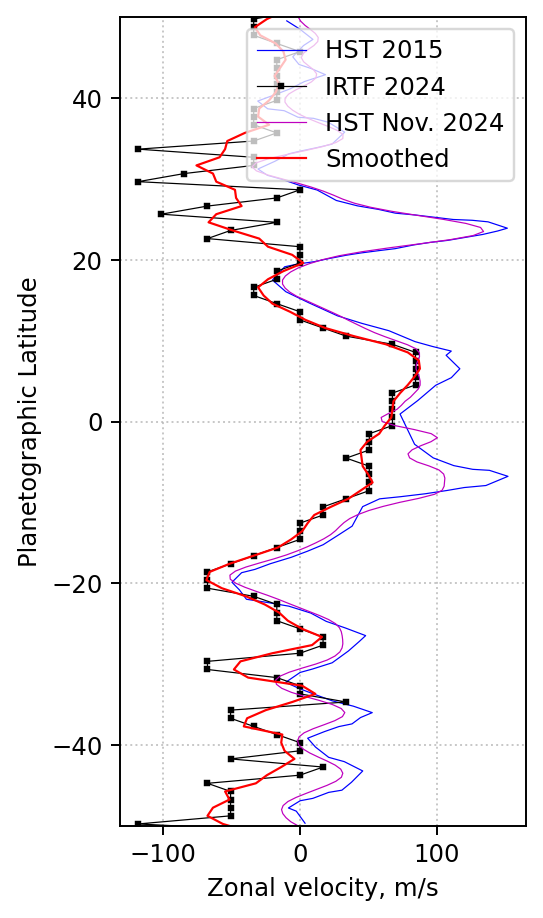

In [ ]:

%matplotlib inline
plt.figure(figsize=(3,6), dpi=175)
plt.plot(hst_wind_1D['x'], hst_wind_1D['y'], color='b', lw=0.5, label='HST 2015')
plt.plot(zwp_5microns, lat_array, marker='s', ms=2, color='k', lw=0.5, label='IRTF 2024')
plt.plot(opal_nov_2024_df['FMZW'][::5], opal_nov_2024_df['LAT'][::5], color='m', lw=0.5, label='HST Nov. 2024')
plt.plot(smooth_zwp_5microns, lat_array, color='r', lw=0.9, label='Smoothed')
plt.ylim(-y_lim_range, y_lim_range)
plt.grid(True, 'both', ls=':', alpha=0.7)
plt.legend(loc='upper right', framealpha=0.75)
plt.xlabel('Zonal velocity, m/s'), plt.ylabel('Planetographic Latitude')
plt.show()

In [ ]:
print(date_meta_list)

output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/'
zwp_output_str = file_list[0].split('/')[1][4:4+3] + '_' + file_list[0].split('/')[2].split('.')[0] + '_' + file_list[1].split('/')[2].split('.')[0]
pair_names = [file_list[0].split('/')[-1], file_list[1].split('/')[-1]]
print(zwp_output_str)
print(pair_names)


['2024-10-22T13:53:25.375', '2024-10-23T10:33:15.97266']
oct_jc451486_jc057087
['jc451486.fits.gz', 'jc057087.fits.gz']


In [ ]:
# # print(file_list[0].split('/')[1][4:4+3])
# # print(file_list[1].split('/')[2].split('.')[0])

# output_path = '/Users/ahyder/Desktop/windfieldproject/spex/outputs/'
# zwp_output_str = file_list[0].split('/')[1][4:4+3] + '_' + file_list[0].split('/')[2].split('.')[0] + '_' + file_list[1].split('/')[2].split('.')[0]
# print(zwp_output_str)

# np.savez_compressed(output_path + zwp_output_str, wind_prof_raw=[zwp_5microns], date_list = date_meta_list, pair_names = pair_names, delta_t_arr = [delta_t], crit_lat=[critical_lat])

# npzfile = np.load(output_path + zwp_output_str + '.npz')

oct_jc451486_jc057087


In [ ]:
npzfile['wind_prof_raw'].shape, npzfile.files

((1, 180),
 ['wind_prof_raw', 'date_list', 'pair_names', 'delta_t_arr', 'crit_lat'])

In [ ]:
fg = [[] for i in range(10)]
fg[0].append(np.array([2,5,6]))

In [ ]:
print(len(fg), fg)

10 [[array([2, 5, 6])], [], [], [], [], [], [], [], [], []]
